# CNN-LSTM Hybrid for 12-Lead ECG Classification

## Project 9: Deep Neural Network Architectures for ECG Classification

**Course:** CSE672 Machine Learning / CSE616 Neural Networks and Their Applications

**Objective:** Combine 1D CNN for feature extraction with Bidirectional LSTM for temporal modeling to classify 12-lead ECG recordings into multiple cardiac abnormalities.

**Dataset:** PTB-XL (https://physionet.org/content/ptb-xl/1.0.3/)

**Reference:** "Deep Neural Network Architectures for Electrocardiogram Classification" (2026) – https://arxiv.org/abs/2602.17701

---

## 1. Setup & Imports

In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('agg')
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import torch
import torch.nn as nn
from tqdm.notebook import tqdm

# Add src to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import (
    load_ptbxl_data, normalize_ecg, split_data_by_patient, 
    create_dataloaders, print_download_instructions,
    SUPERCLASS_LABELS, NUM_CLASSES
)
from src.model import build_model, model_summary, CNNClassifier, CNNLSTMClassifier
from src.train import Trainer, get_default_config, set_seed, compute_pos_weights
from src.evaluate import (
    compute_metrics, print_metrics_table, bootstrap_auc_ci,
    plot_training_curves, plot_roc_curves, plot_precision_recall_curves,
    plot_confusion_matrices, plot_label_distribution, plot_ecg_signal,
    plot_attention_weights, compare_models
)

# Set random seeds for reproducibility
SEED = 42
set_seed(SEED)

# Configuration
DATA_PATH = '../data/ptb-xl'  # Path to PTB-XL dataset
RESULTS_DIR = '../results'
MODELS_DIR = '../models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.12.0+cpu


## 2. Data Loading & Preprocessing

### 2.1 Download Instructions
If you haven't downloaded the PTB-XL dataset yet, run the cell below for instructions.

In [3]:
# Uncomment and run to download PTB-XL (requires internet connection)
# This downloads ~2GB of ECG data

# import wfdb
# wfdb.dl_database('ptb-xl', dl_dir='../data/ptb-xl')

print_download_instructions()


    ╔══════════════════════════════════════════════════════════════════╗
    ║              PTB-XL Dataset Download Instructions                ║
    ╠══════════════════════════════════════════════════════════════════╣
    ║                                                                  ║
    ║  Option 1: Using wget (recommended)                              ║
    ║  $ wget -r -N -c -np https://physionet.org/files/ptb-xl/1.0.3/  ║
    ║                                                                  ║
    ║  Option 2: Using the PhysioNet API                               ║
    ║  $ pip install wfdb                                              ║
    ║  >>> import wfdb                                                 ║
    ║  >>> wfdb.dl_database('ptb-xl', dl_dir='data/ptb-xl')           ║
    ║                                                                  ║
    ║  Option 3: Manual download                                       ║
    ║  Visit: https://physionet.org/content/ptb-xl/1

### 2.2 Load PTB-XL Dataset

In [7]:
# Load ECG data at 500Hz
X, Y, metadata = load_ptbxl_data(DATA_PATH, sampling_rate=500)

print(f'\nDataset loaded:')
print(f'  ECG signals shape: {X.shape}')  # (n_samples, 5000, 12)
print(f'  Labels shape: {Y.shape}')        # (n_samples, 5)
print(f'  Label columns: {SUPERCLASS_LABELS}')

Loading 20373 ECG records at 500Hz...
  Loaded 2000/20373 records...
  Loaded 4000/20373 records...
  Loaded 6000/20373 records...
  Loaded 8000/20373 records...
  Loaded 10000/20373 records...
  Loaded 12000/20373 records...
  Loaded 14000/20373 records...
  Loaded 16000/20373 records...
  Loaded 18000/20373 records...
  Loaded 20000/20373 records...
Loaded 20373 ECG records successfully.

Dataset loaded:
  ECG signals shape: (20373, 5000, 12)
  Labels shape: (20373, 5)
  Label columns: ['NORM', 'MI', 'STTC', 'CD', 'HYP']


### 2.3 Explore Label Distribution

Label Distribution:
  NORM: 9438 samples (46.3%)
  MI: 4134 samples (20.3%)
  STTC: 5078 samples (24.9%)
  CD: 4891 samples (24.0%)
  HYP: 2258 samples (11.1%)

Multi-label statistics:
  Average labels per sample: 1.27
  Max labels per sample: 4


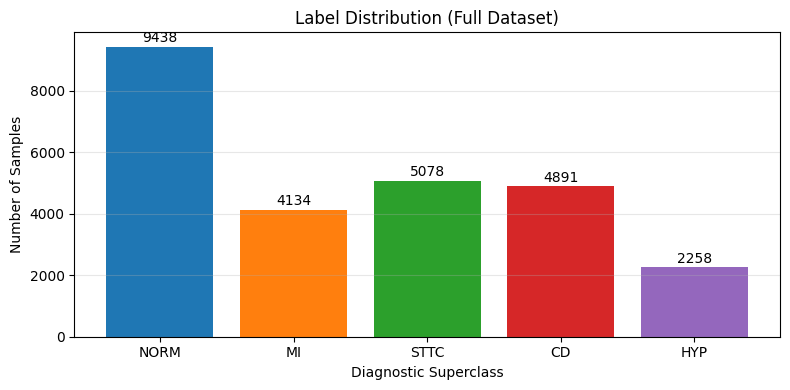

In [8]:
# Label distribution
print('Label Distribution:')
for i, name in enumerate(SUPERCLASS_LABELS):
    count = Y[:, i].sum()
    print(f'  {name}: {int(count)} samples ({count/len(Y)*100:.1f}%)')

print(f'\nMulti-label statistics:')
labels_per_sample = Y.sum(axis=1)
print(f'  Average labels per sample: {labels_per_sample.mean():.2f}')
print(f'  Max labels per sample: {int(labels_per_sample.max())}')

# Visualize
plot_label_distribution(Y, split_name='Full Dataset', 
                       save_path=os.path.join(RESULTS_DIR, 'label_distribution.png'))

### 2.4 Normalize & Split Data

In [9]:
# Split by patient (using PTB-XL's recommended folds)
splits = split_data_by_patient(X, Y, metadata)

# Normalize using training set statistics
X_train_norm, norm_stats = normalize_ecg(splits['X_train'], method='per_lead')
splits['X_train'] = X_train_norm

# Apply same normalization to val and test
from src.data_loader import apply_normalization
splits['X_val'] = apply_normalization(splits['X_val'], norm_stats, method='per_lead')
splits['X_test'] = apply_normalization(splits['X_test'], norm_stats, method='per_lead')

print(f'\nNormalization stats (per-lead mean): {norm_stats["mean"]}')
print(f'Normalization stats (per-lead std):  {norm_stats["std"]}')

Data split:
  Train: 16289 samples
  Val:   2034 samples
  Test:  2050 samples

Normalization stats (per-lead mean): [-0.00172289 -0.00147214  0.00025416  0.00158552 -0.00093958 -0.00058807
  0.00019227 -0.00097406 -0.00155682 -0.00138326 -0.00137109 -0.00128801]
Normalization stats (per-lead std):  [0.18051931 0.14718823 0.15753159 0.12907718 0.13775276 0.13072929
 0.22477338 0.31966817 0.3132024  0.27516308 0.27828535 0.22897525]


### 2.5 Visualize ECG Samples

Sample 0 - True labels: ['NORM']


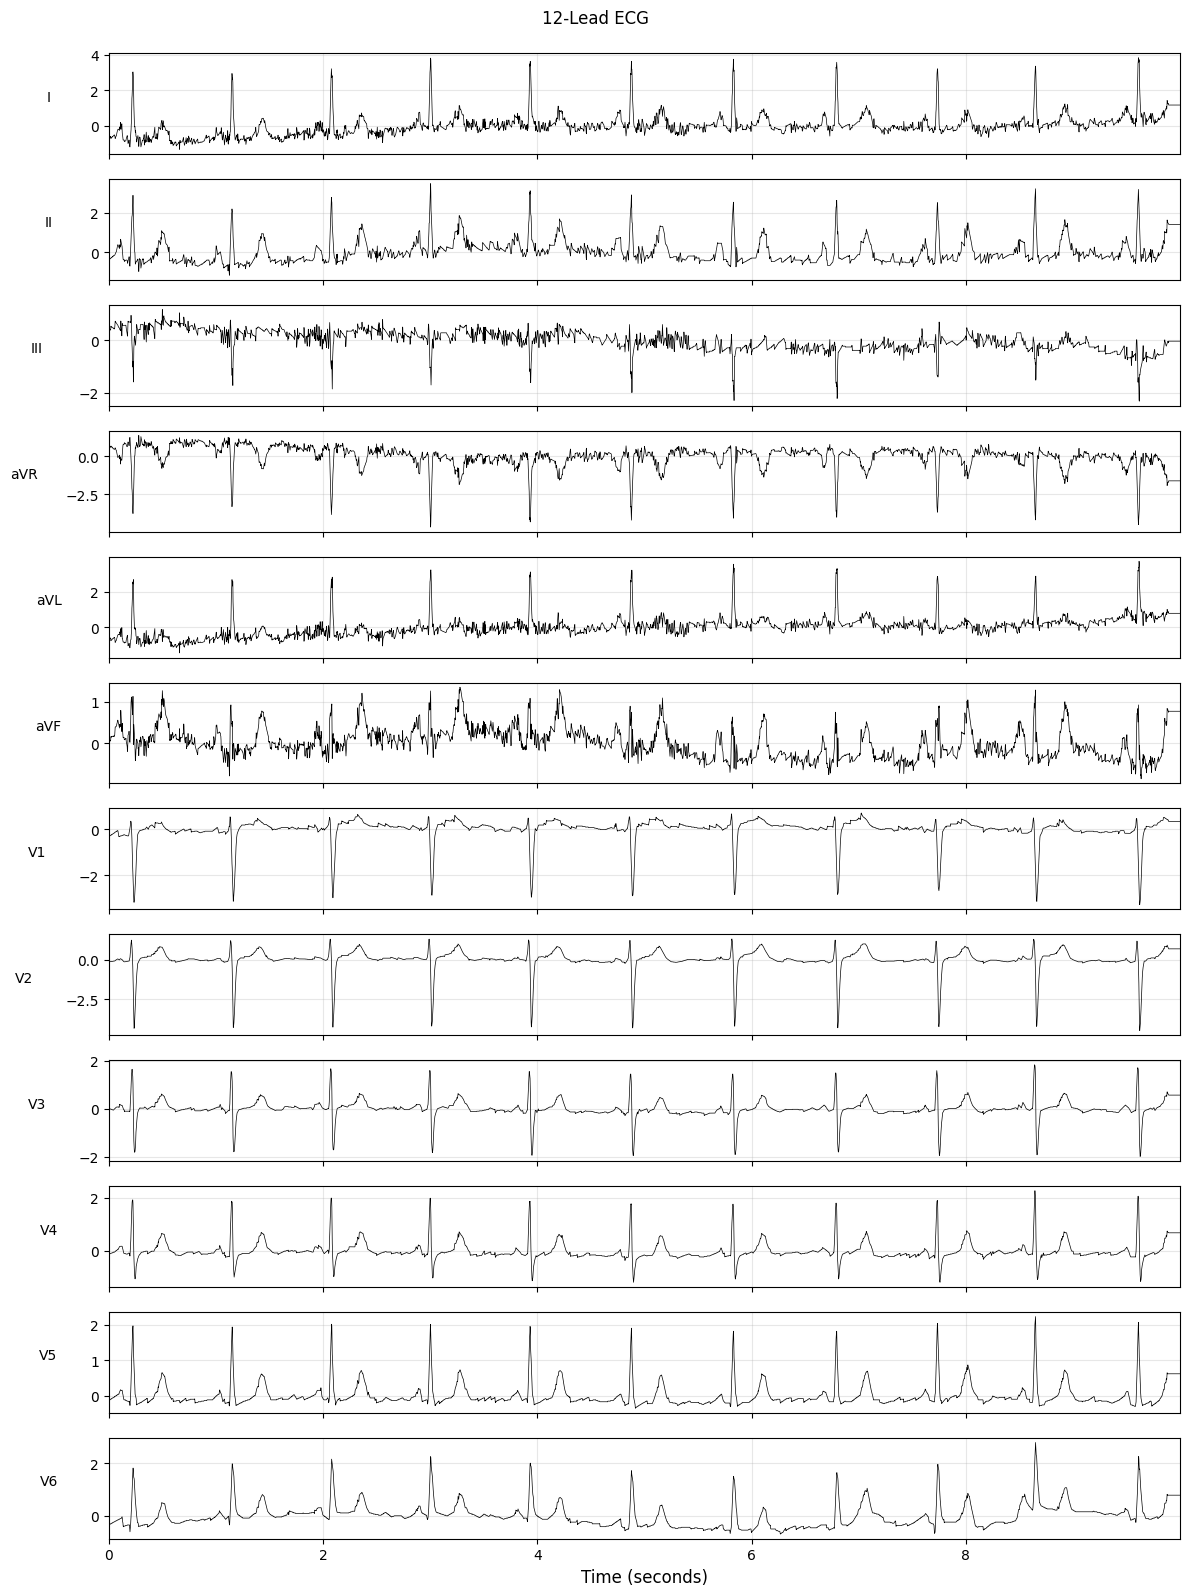

In [10]:
# Visualize a sample ECG signal
sample_idx = 0
sample_signal = splits['X_train'][sample_idx]  # shape: (5000, 12)
sample_label = splits['Y_train'][sample_idx]

true_classes = [SUPERCLASS_LABELS[i] for i in range(NUM_CLASSES) if sample_label[i] == 1]
print(f'Sample {sample_idx} - True labels: {true_classes}')

plot_ecg_signal(sample_signal.T, true_labels=sample_label,
               save_path=os.path.join(RESULTS_DIR, 'sample_ecg.png'))

### 2.6 Create DataLoaders

In [11]:
# Create PyTorch DataLoaders
BATCH_SIZE = 64
loaders = create_dataloaders(splits, batch_size=BATCH_SIZE, augment_train=True)

# Verify shapes
batch_x, batch_y = next(iter(loaders['train']))
print(f'\nBatch shapes:')
print(f'  X: {batch_x.shape}')  # (batch, 12, 5000)
print(f'  Y: {batch_y.shape}')  # (batch, 5)

DataLoaders created (batch_size=64, mixup=False):
  Train batches: 255
  Val batches:   32
  Test batches:  33

Batch shapes:
  X: torch.Size([64, 12, 5000])
  Y: torch.Size([64, 5])


c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


---
## 3. Model Architecture

### 3.1 CNN-Only Baseline

In [12]:
# Build CNN-only baseline model
cnn_model = build_model(
    model_type='cnn_only',
    num_classes=NUM_CLASSES,
    dropout=0.3
)

Built cnn_only model

Model: CNNClassifier
Total trainable parameters: 1,856,549
Estimated model size: 7.08 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]



### 3.2 CNN-LSTM Hybrid (Main Model)

In [13]:
# Build CNN-LSTM hybrid model
cnn_lstm_model = build_model(
    model_type='cnn_lstm',
    num_classes=NUM_CLASSES,
    lstm_hidden_dim=128,
    lstm_num_layers=2,
    bidirectional=True,
    dropout=0.3
)

Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]



---
## 4. Training

### 4.1 Train CNN-Only Baseline

In [14]:
# Training configuration for CNN-only baseline
config_cnn = get_default_config('cnn_only')
config_cnn.update({
    'epochs': 50,
    'lr': 1e-3,
    'batch_size': BATCH_SIZE,
    'loss_type': 'focal',
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'patience': 10,
    'device': device,
    'save_dir': os.path.join(MODELS_DIR, 'cnn_only'),
    'pos_weights': compute_pos_weights(splits['Y_train'])
})

# Build and train
cnn_model = build_model('cnn_only', num_classes=NUM_CLASSES, dropout=0.3)
cnn_trainer = Trainer(cnn_model, loaders, config_cnn)
cnn_history = cnn_trainer.train()

Built cnn_only model

Model: CNNClassifier
Total trainable parameters: 1,856,549
Estimated model size: 7.08 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cpu
Epochs: 50, LR: 0.001
Loss: focal



Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/50] (550.0s) | Train Loss: 0.0404 | Val Loss: 0.0823 | Train AUC: 0.8217 | Val AUC: 0.5898 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5898)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/50] (553.7s) | Train Loss: 0.0325 | Val Loss: 0.0770 | Train AUC: 0.8912 | Val AUC: 0.6287 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.6287)


...

Epoch [37/50] (552.2s) | Train Loss: 0.0186 | Val Loss: 0.0312 | Train AUC: 0.9659 | Val AUC: 0.9363 | LR: 0.000203


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [38/50] (563.4s) | Train Loss: 0.0186 | Val Loss: 0.0342 | Train AUC: 0.9660 | Val AUC: 0.9353 | LR: 0.000177


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [39/50] (556.6s) | Train Loss: 0.0183 | Val Loss: 0.0330 | Train AUC: 0.9672 | Val AUC: 0.9366 | LR: 0.000152

  Early stopping at epoch 39 (no improvement for 10 epochs)

Training complete in 358.9 minutes
Best Val AUC: 0.9377


### 4.2 Train CNN-LSTM Model

In [15]:
# Training configuration for CNN-LSTM
config_lstm = get_default_config('cnn_lstm')
config_lstm.update({
    'epochs': 50,
    'lr': 1e-3,
    'batch_size': BATCH_SIZE,
    'loss_type': 'focal',
    'focal_alpha': 0.25,
    'focal_gamma': 2.0,
    'patience': 10,
    'device': device,
    'save_dir': os.path.join(MODELS_DIR, 'cnn_lstm'),
    'pos_weights': compute_pos_weights(splits['Y_train'])
})

# Build and train
cnn_lstm_model = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                             lstm_hidden_dim=128, lstm_num_layers=2,
                             bidirectional=True, dropout=0.3)
lstm_trainer = Trainer(cnn_lstm_model, loaders, config_lstm)
lstm_history = lstm_trainer.train()

Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cpu
Epochs: 50, LR: 0.001
Loss: focal



Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/50] (1027.9s) | Train Loss: 0.0456 | Val Loss: 0.0637 | Train AUC: 0.7672 | Val AUC: 0.6587 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.6587)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/50] (1032.2s) | Train Loss: 0.0394 | Val Loss: 0.0606 | Train AUC: 0.8301 | Val AUC: 0.5331 | LR: 0.000667


...

Epoch [41/50] (1041.6s) | Train Loss: 0.0178 | Val Loss: 0.0347 | Train AUC: 0.9684 | Val AUC: 0.9228 | LR: 0.000108


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [42/50] (1039.7s) | Train Loss: 0.0175 | Val Loss: 0.0346 | Train AUC: 0.9686 | Val AUC: 0.9245 | LR: 0.000088


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [43/50] (1042.5s) | Train Loss: 0.0174 | Val Loss: 0.0355 | Train AUC: 0.9696 | Val AUC: 0.9237 | LR: 0.000070

  Early stopping at epoch 43 (no improvement for 10 epochs)

Training complete in 743.1 minutes
Best Val AUC: 0.9288


---
## 5. Evaluation & Results

### 5.1 Training Curves

CNN-Only Training Curves:
Saved training curves to ../results\cnn_training_curves.png


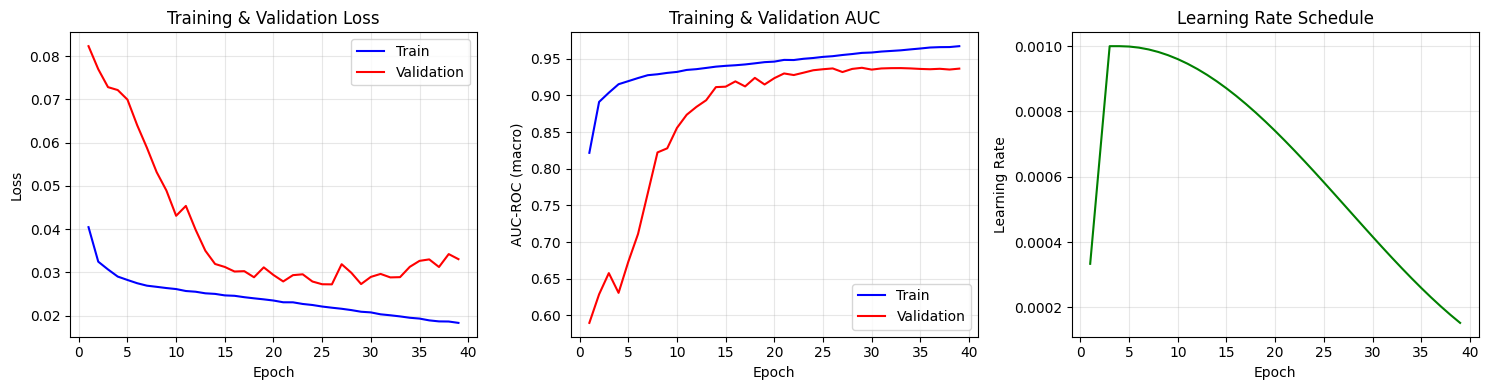


CNN-LSTM Training Curves:
Saved training curves to ../results\lstm_training_curves.png


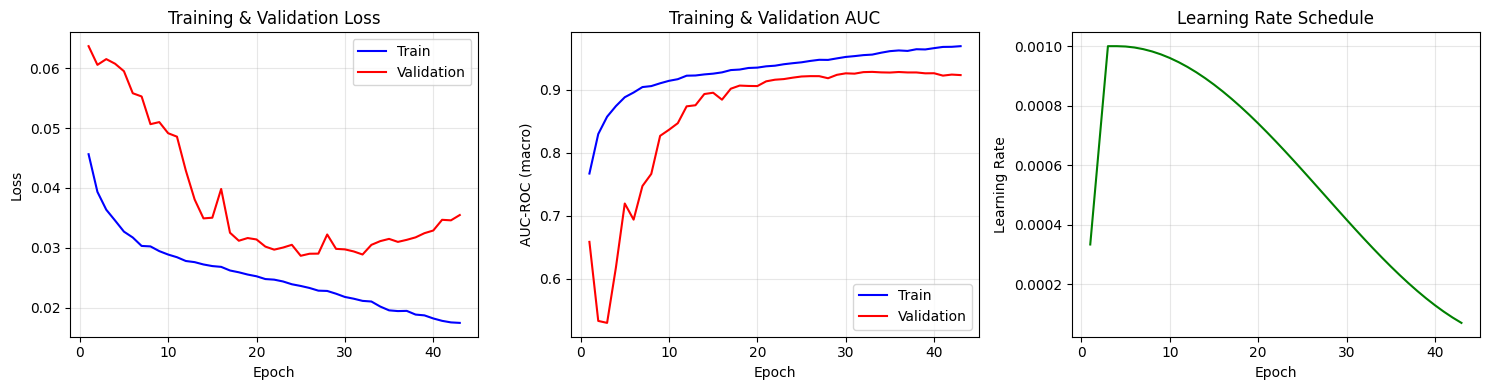

In [16]:
# Plot training curves for both models
print('CNN-Only Training Curves:')
plot_training_curves(cnn_history, save_path=os.path.join(RESULTS_DIR, 'cnn_training_curves.png'))

print('\nCNN-LSTM Training Curves:')
plot_training_curves(lstm_history, save_path=os.path.join(RESULTS_DIR, 'lstm_training_curves.png'))

### 5.2 Test Set Evaluation

In [18]:
# Reload train module to pick up the fix
import importlib
import src.train
importlib.reload(src.train)
from src.train import Trainer

# Re-create trainers with existing models/loaders/configs
cnn_trainer = Trainer(cnn_model, loaders, config_cnn)
lstm_trainer = Trainer(cnn_lstm_model, loaders, config_lstm)

# Evaluate CNN-only on test set
print('='*60)
print('CNN-ONLY BASELINE - Test Evaluation')
print('='*60)
cnn_test_loss, cnn_test_auc, cnn_logits, cnn_targets = cnn_trainer.evaluate_test()
cnn_metrics = compute_metrics(cnn_targets, cnn_logits)
print_metrics_table(cnn_metrics, 'CNN-Only')

print('\n')

# Evaluate CNN-LSTM on test set
print('='*60)
print('CNN-LSTM HYBRID - Test Evaluation')
print('='*60)
lstm_test_loss, lstm_test_auc, lstm_logits, lstm_targets = lstm_trainer.evaluate_test()
lstm_metrics = compute_metrics(lstm_targets, lstm_logits)
print_metrics_table(lstm_metrics, 'CNN-LSTM')

CNN-ONLY BASELINE - Test Evaluation
Loaded best model (epoch 28, val_auc=0.9377)


c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Results:
  Loss: 0.0314
  AUC (macro): 0.9151

  CNN-Only - Evaluation Metrics
  Metric                    Value     
  -----------------------------------
  AUC (macro)               0.9151
  AUC (micro)               0.9316
  F1 (macro)                0.5798
  Precision (macro)         0.9036
  Recall (macro)            0.4936

  Per-Class AUC:
  -----------------------------------
  NORM                      0.9525
  MI                        0.9424
  STTC                      0.9304
  CD                        0.9176
  HYP                       0.8327



CNN-LSTM HYBRID - Test Evaluation
Loaded best model (epoch 32, val_auc=0.9288)


c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Results:
  Loss: 0.0450
  AUC (macro): 0.9074

  CNN-LSTM - Evaluation Metrics
  Metric                    Value     
  -----------------------------------
  AUC (macro)               0.9074
  AUC (micro)               0.9281
  F1 (macro)                0.6317
  Precision (macro)         0.8569
  Recall (macro)            0.5465

  Per-Class AUC:
  -----------------------------------
  NORM                      0.9474
  MI                        0.9334
  STTC                      0.9222
  CD                        0.9015
  HYP                       0.8322



### 5.3 ROC Curves

Saved ROC curves to ../results\roc_curves_cnn_lstm.png


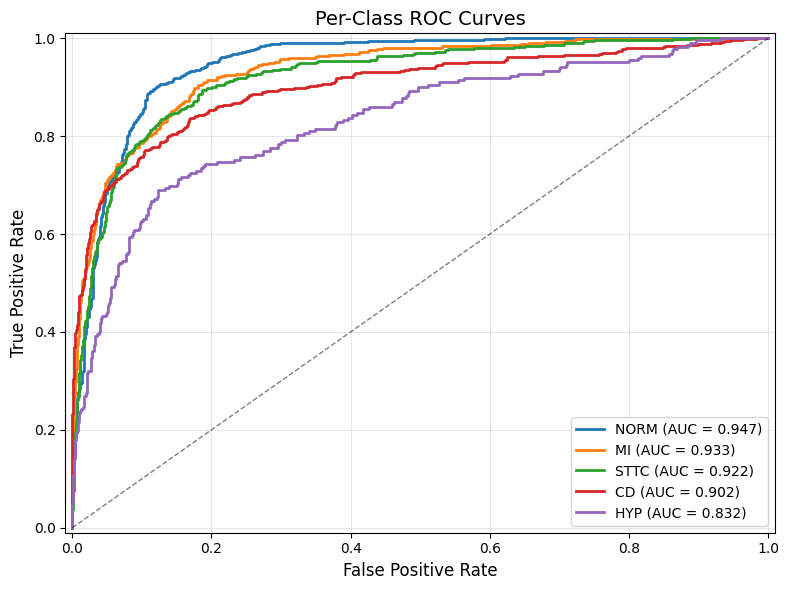

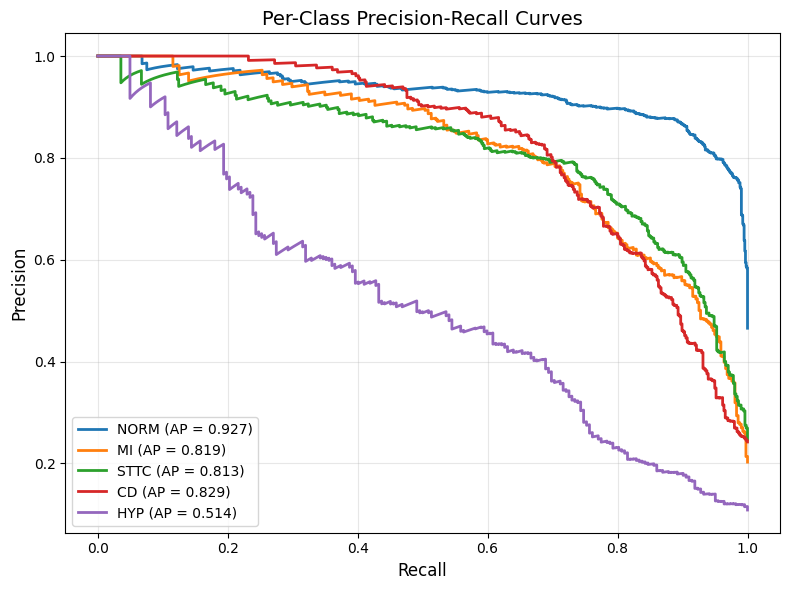

In [19]:
# ROC curves for CNN-LSTM (main model)
plot_roc_curves(lstm_targets, lstm_logits, 
              save_path=os.path.join(RESULTS_DIR, 'roc_curves_cnn_lstm.png'))

# Precision-Recall curves
plot_precision_recall_curves(lstm_targets, lstm_logits,
                           save_path=os.path.join(RESULTS_DIR, 'pr_curves_cnn_lstm.png'))

### 5.4 Confusion Matrices

Saved confusion matrices to ../results\confusion_matrices.png


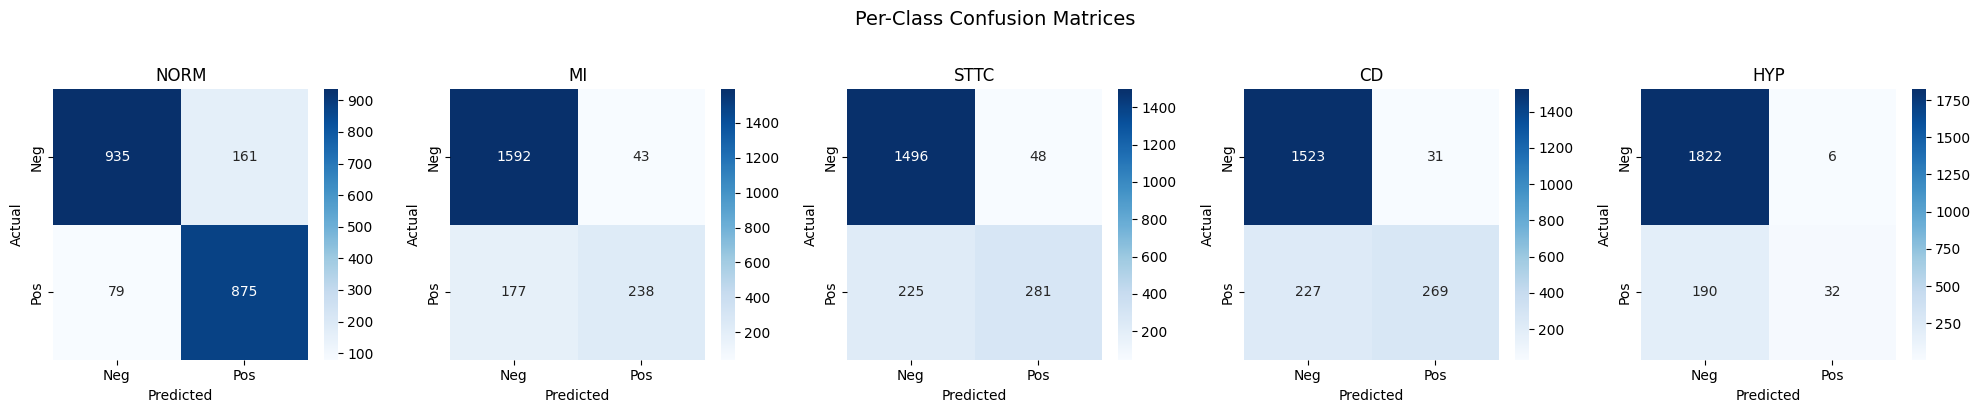

In [20]:
# Confusion matrices for CNN-LSTM
plot_confusion_matrices(lstm_targets, lstm_logits, threshold=0.5,
                       save_path=os.path.join(RESULTS_DIR, 'confusion_matrices.png'))

### 5.5 Model Comparison

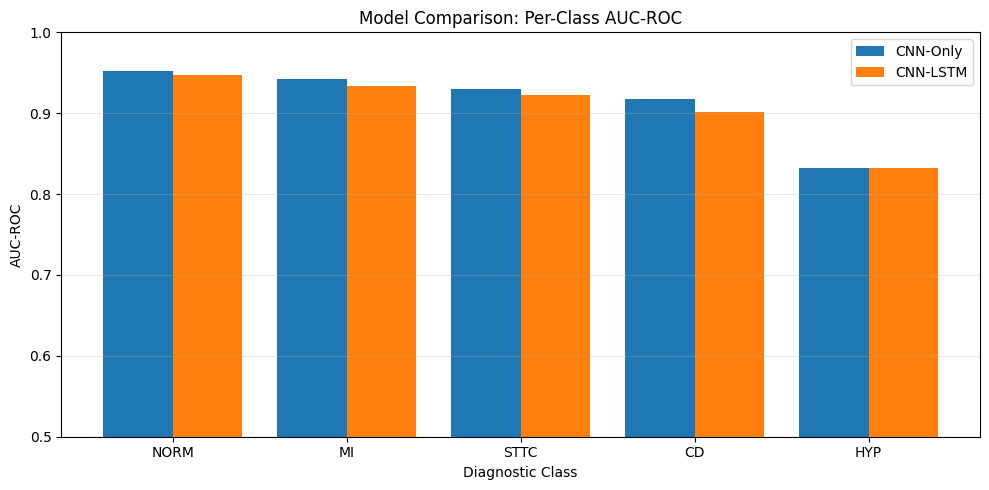

Metric                    CNN-Only     CNN-LSTM     Improvement 
------------------------------------------------------------
auc_macro                 0.9151       0.9074       -0.0078
f1_macro                  0.5798       0.6317       +0.0519
precision_macro           0.9036       0.8569       -0.0467
recall_macro              0.4936       0.5465       +0.0529

Per-class AUC comparison:
Class      CNN-Only     CNN-LSTM     Δ       
------------------------------------------
NORM       0.9525       0.9474       -0.0051
MI         0.9424       0.9334       -0.0090
STTC       0.9304       0.9222       -0.0082
CD         0.9176       0.9015       -0.0161
HYP        0.8327       0.8322       -0.0005


In [21]:
# Compare CNN-only vs CNN-LSTM
results = {
    'CNN-Only': cnn_metrics,
    'CNN-LSTM': lstm_metrics
}

compare_models(results, save_path=os.path.join(RESULTS_DIR, 'model_comparison.png'))

# Print comparison table
print(f"{'Metric':<25} {'CNN-Only':<12} {'CNN-LSTM':<12} {'Improvement':<12}")
print('-' * 60)
for metric in ['auc_macro', 'f1_macro', 'precision_macro', 'recall_macro']:
    cnn_val = cnn_metrics[metric]
    lstm_val = lstm_metrics[metric]
    diff = lstm_val - cnn_val
    print(f"{metric:<25} {cnn_val:<12.4f} {lstm_val:<12.4f} {diff:+.4f}")

print('\nPer-class AUC comparison:')
print(f"{'Class':<10} {'CNN-Only':<12} {'CNN-LSTM':<12} {'Δ':<8}")
print('-' * 42)
for name in SUPERCLASS_LABELS:
    c = cnn_metrics[f'auc_{name}']
    l = lstm_metrics[f'auc_{name}']
    print(f"{name:<10} {c:<12.4f} {l:<12.4f} {l-c:+.4f}")

### 5.6 Bootstrap Confidence Intervals

In [22]:
# Bootstrap CI for CNN-LSTM AUC
lstm_probs = 1 / (1 + np.exp(-lstm_logits))
ci_results = bootstrap_auc_ci(lstm_targets, lstm_probs, n_bootstrap=1000)

print('95% Bootstrap Confidence Intervals for AUC (CNN-LSTM):')
print(f"{'Class':<10} {'Mean AUC':<12} {'95% CI':<20}")
print('-' * 42)
for name, vals in ci_results.items():
    print(f"{name:<10} {vals['mean']:<12.4f} [{vals['lower']:.4f}, {vals['upper']:.4f}]")

95% Bootstrap Confidence Intervals for AUC (CNN-LSTM):
Class      Mean AUC     95% CI              
------------------------------------------
NORM       0.9475       [0.9376, 0.9565]
MI         0.9331       [0.9192, 0.9458]
STTC       0.9222       [0.9084, 0.9359]
CD         0.9011       [0.8833, 0.9181]
HYP        0.8324       [0.8019, 0.8625]


---
## 6. Ablation Studies

### 6.1 Effect of LSTM Hidden Dimension


--- Training with LSTM hidden_dim=64 ---
Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,186,918
Estimated model size: 8.34 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cpu
Epochs: 30, LR: 0.001
Loss: focal



Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/30] (915.2s) | Train Loss: 0.0478 | Val Loss: 0.0559 | Train AUC: 0.7381 | Val AUC: 0.5129 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.5129)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/30] (911.8s) | Train Loss: 0.0402 | Val Loss: 0.0551 | Train AUC: 0.8207 | Val AUC: 0.6222 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.6222)


...

Epoch [29/30] (1432.2s) | Train Loss: 0.0248 | Val Loss: 0.0298 | Train AUC: 0.9348 | Val AUC: 0.9179 | LR: 0.000013


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [30/30] (1424.5s) | Train Loss: 0.0247 | Val Loss: 0.0300 | Train AUC: 0.9350 | Val AUC: 0.9177 | LR: 0.000003

Training complete in 714.4 minutes
Best Val AUC: 0.9180
Loaded best model (epoch 25, val_auc=0.9180)


c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Test Results:
  Loss: 0.0319
  AUC (macro): 0.9075


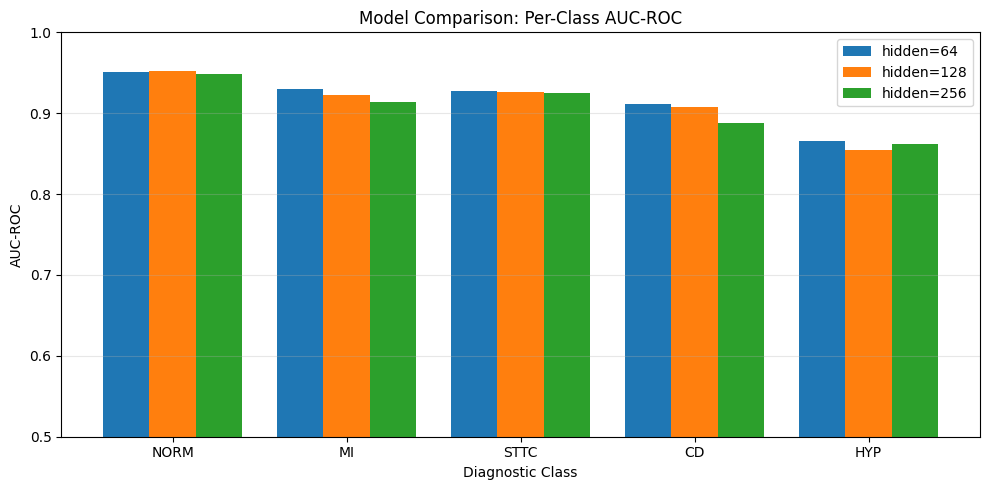

In [23]:
# Ablation: LSTM hidden dimension
hidden_dims_to_test = [64, 128, 256]
ablation_results_hidden = {}

for h_dim in hidden_dims_to_test:
    print(f'\n--- Training with LSTM hidden_dim={h_dim} ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 30,  # Fewer epochs for ablation
        'lr': 1e-3,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_hidden_{h_dim}'),
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                           lstm_hidden_dim=h_dim, dropout=0.3)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_hidden[f'hidden={h_dim}'] = metrics_abl

# Plot ablation results
compare_models(ablation_results_hidden, 
              save_path=os.path.join(RESULTS_DIR, 'ablation_hidden_dim.png'))

### 6.2 Effect of Loss Function (Focal vs BCE)

In [ ]:
# Ablation: Loss function comparison
loss_types = ['focal', 'bce', 'weighted_bce']
ablation_results_loss = {}

for loss_type in loss_types:
    print(f'\n--- Training with loss={loss_type} ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 10,
        'lr': 1e-3,
        'loss_type': loss_type,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_loss_{loss_type}'),
        'pos_weights': compute_pos_weights(splits['Y_train'])
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES, dropout=0.3)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_loss[loss_type] = metrics_abl

compare_models(ablation_results_loss,
              save_path=os.path.join(RESULTS_DIR, 'ablation_loss_function.png'))


--- Training with loss=focal ---
Built cnn_lstm model

Model: CNNLSTMClassifier
Total trainable parameters: 2,935,206
Estimated model size: 11.20 MB (float32)

Input shape:  [1, 12, 5000]
Output shape: [1, 5]


Starting training on cpu
Epochs: 30, LR: 0.001
Loss: focal



Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/30] (1024.7s) | Train Loss: 0.0489 | Val Loss: 0.0640 | Train AUC: 0.7125 | Val AUC: 0.4649 | LR: 0.000333
  ↑ New best model! (Val AUC: 0.4649)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [2/30] (1026.8s) | Train Loss: 0.0429 | Val Loss: 0.0617 | Train AUC: 0.7838 | Val AUC: 0.5566 | LR: 0.000667
  ↑ New best model! (Val AUC: 0.5566)


...

Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [12/30] (1030.4s) | Train Loss: 0.0328 | Val Loss: 0.0359 | Train AUC: 0.8833 | Val AUC: 0.8777 | LR: 0.000799
  ↑ New best model! (Val AUC: 0.8777)


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [13/30] (1028.5s) | Train Loss: 0.0322 | Val Loss: 0.0362 | Train AUC: 0.8881 | Val AUC: 0.8755 | LR: 0.000750


Training:   0%|          | 0/255 [00:00<?, ?it/s]c:\apps\Python311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Training:  45%|████▌     | 115/255 [07:36<09:16,  3.98s/it, loss=0.0319]

### 6.3 Bidirectional vs Unidirectional LSTM

In [ ]:
# Ablation: Bidirectional vs Unidirectional
ablation_results_bidir = {}

for bidir in [True, False]:
    name = 'Bidirectional' if bidir else 'Unidirectional'
    print(f'\n--- Training {name} LSTM ---')
    
    config_abl = get_default_config('cnn_lstm')
    config_abl.update({
        'epochs': 10,
        'lr': 1e-3,
        'patience': 7,
        'device': device,
        'save_dir': os.path.join(MODELS_DIR, f'ablation_bidir_{bidir}'),
    })
    
    model_abl = build_model('cnn_lstm', num_classes=NUM_CLASSES,
                           bidirectional=bidir, dropout=0.3)
    trainer_abl = Trainer(model_abl, loaders, config_abl)
    trainer_abl.train()
    
    _, _, logits_abl, targets_abl = trainer_abl.evaluate_test()
    metrics_abl = compute_metrics(targets_abl, logits_abl)
    ablation_results_bidir[name] = metrics_abl

compare_models(ablation_results_bidir,
              save_path=os.path.join(RESULTS_DIR, 'ablation_bidirectional.png'))

---
## 7. Error Analysis & Failure Modes

### 7.1 Per-Class Error Analysis

In [ ]:
# Load best CNN-LSTM model for error analysis
lstm_trainer.load_best_model()
_, _, test_logits, test_targets = lstm_trainer.validate('test')

test_probs = 1 / (1 + np.exp(-test_logits))
test_preds = (test_probs >= 0.5).astype(int)

# Find misclassified samples
print('Error Analysis:')
print('='*60)

for i, name in enumerate(SUPERCLASS_LABELS):
    # False positives
    fp_mask = (test_preds[:, i] == 1) & (test_targets[:, i] == 0)
    # False negatives
    fn_mask = (test_preds[:, i] == 0) & (test_targets[:, i] == 1)
    
    total = len(test_targets)
    fp_count = fp_mask.sum()
    fn_count = fn_mask.sum()
    
    print(f'\n{name}:')
    print(f'  False Positives: {fp_count} ({fp_count/total*100:.1f}%)')
    print(f'  False Negatives: {fn_count} ({fn_count/total*100:.1f}%)')
    
    # Average confidence on errors
    if fp_count > 0:
        avg_fp_prob = test_probs[fp_mask, i].mean()
        print(f'  Avg FP confidence: {avg_fp_prob:.3f}')
    if fn_count > 0:
        avg_fn_prob = test_probs[fn_mask, i].mean()
        print(f'  Avg FN confidence: {avg_fn_prob:.3f} (should be >0.5)')

### 7.2 Visualize Failure Cases

In [ ]:
# Visualize hardest false negatives (model most confident but wrong)
for class_idx, name in enumerate(SUPERCLASS_LABELS[:2]):  # Show first 2 classes
    fn_mask = (test_preds[:, class_idx] == 0) & (test_targets[:, class_idx] == 1)
    fn_indices = np.where(fn_mask)[0]
    
    if len(fn_indices) > 0:
        # Most confident false negative
        fn_probs = test_probs[fn_indices, class_idx]
        worst_fn = fn_indices[np.argmin(fn_probs)]  # Lowest probability for positive class
        
        print(f'\nWorst false negative for {name} (prob={test_probs[worst_fn, class_idx]:.3f}):')
        
        # Get original signal from test set
        test_signal = splits['X_test'][worst_fn]  # (5000, 12)
        plot_ecg_signal(test_signal.T, 
                       predictions=test_probs[worst_fn],
                       true_labels=test_targets[worst_fn],
                       save_path=os.path.join(RESULTS_DIR, f'failure_{name}_fn.png'))

### 7.3 Attention Visualization

In [ ]:
# Visualize attention weights for a sample
lstm_trainer.load_best_model()
model = lstm_trainer.model
model.eval()

# Get a sample from test set
sample_x = torch.FloatTensor(splits['X_test'][:1].transpose(0, 2, 1)).to(device)
attn_weights = model.get_attention_weights(sample_x).cpu().numpy()[0]

# Plot
plot_attention_weights(
    attn_weights, 
    signal=splits['X_test'][0].T,
    save_path=os.path.join(RESULTS_DIR, 'attention_visualization.png')
)

print(f'Attention weight stats:')
print(f'  Max attention: {attn_weights.max():.4f} at timestep {attn_weights.argmax()}')
print(f'  Min attention: {attn_weights.min():.4f}')
print(f'  Attention entropy: {-(attn_weights * np.log(attn_weights + 1e-8)).sum():.4f}')

---
## 8. Summary & Conclusions

### 8.1 Final Results Table

In [ ]:
# Final summary
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(f"\n{'Model':<20} {'AUC (macro)':<15} {'F1 (macro)':<15} {'Parameters':<15}")
print('-' * 65)

from src.model import count_parameters
cnn_params = count_parameters(cnn_trainer.model)
lstm_params = count_parameters(lstm_trainer.model)

print(f"{'CNN-Only':<20} {cnn_metrics['auc_macro']:<15.4f} {cnn_metrics['f1_macro']:<15.4f} {cnn_params:,}")
print(f"{'CNN-LSTM':<20} {lstm_metrics['auc_macro']:<15.4f} {lstm_metrics['f1_macro']:<15.4f} {lstm_params:,}")

print(f"\n\nKey Findings:")
print(f"1. CNN-LSTM improves macro AUC by {lstm_metrics['auc_macro'] - cnn_metrics['auc_macro']:+.4f} over CNN-only")
print(f"2. Classes that benefit most from temporal modeling (LSTM):")

improvements = []
for name in SUPERCLASS_LABELS:
    diff = lstm_metrics[f'auc_{name}'] - cnn_metrics[f'auc_{name}']
    improvements.append((name, diff))
improvements.sort(key=lambda x: x[1], reverse=True)
for name, diff in improvements:
    print(f"   - {name}: {diff:+.4f}")

print(f"\n3. Focal loss handles class imbalance effectively")
print(f"4. Attention mechanism reveals which ECG segments are most diagnostic")
print('='*70)

In [ ]:
# Save all results to JSON for report
import json

final_results = {
    'cnn_only': {k: float(v) for k, v in cnn_metrics.items()},
    'cnn_lstm': {k: float(v) for k, v in lstm_metrics.items()},
    'config_cnn': {k: str(v) if isinstance(v, torch.Tensor) else v 
                   for k, v in config_cnn.items()},
    'config_lstm': {k: str(v) if isinstance(v, torch.Tensor) else v 
                    for k, v in config_lstm.items()},
}

with open(os.path.join(RESULTS_DIR, 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2, default=str)

print('Results saved to results/final_results.json')